<a href="https://colab.research.google.com/github/JWasonga/Statistical_Data_Analytics/blob/Applied_Statistics_and_Econometrics-_Portfolio/1_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Rain Prediction (Australia) - Exploratory Data Analysis

Predict whether it rains the next day at a given Australian weather station using daily measurements (temperature, humidity, wind, pressure) ftom the kaggle weatherAUS dataset (~ 145,000 rows across 49 stations 2007-2017).

**Target `RainTomorrow` (0 = No Rain, 1 = Rain)

#1. Imports and Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings; warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)
%matplotlib inline

In [2]:
from google.colab import files
uploaded = files.upload()

Saving weatherAUS.csv to weatherAUS.csv


In [5]:
df = pd.read_csv('weatherAUS.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (145460, 23)


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,WNW,20.0,24.0,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,WSW,4.0,22.0,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,WSW,19.0,26.0,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,E,11.0,9.0,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,NW,7.0,20.0,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [6]:
# percentage of missing values for each column
missing_percentages = df.isnull().sum() / len(df) * 100

# threshold for dropping columns (e.g., 70% missing)
threshold = 70

# Identify columns to drop
columns_to_drop = missing_percentages[missing_percentages > threshold].index.tolist()

print(f"Columns to be dropped due to more than {threshold}% missing values: {columns_to_drop}")

# Drop the identified columns
df = df.drop(columns=columns_to_drop)

print(f"Shape after dropping high-NaN columns: {df.shape}")

Columns to be dropped due to more than 70% missing values: []
Shape after dropping high-NaN columns: (145460, 23)


In [7]:
# Drop rows where the target variable 'RainTomorrow' is NaN
df.dropna(subset=['RainTomorrow'], inplace=True)

print(f"Shape after dropping rows with NaN in 'RainTomorrow': {df.shape}")

Shape after dropping rows with NaN in 'RainTomorrow': (142193, 23)


In [13]:
if 'Date' in df.columns:
    # Convert 'Date' column to datetime objects
    df['Date'] = pd.to_datetime(df['Date'])

    df['Year'] = df['Date'].dt.year
    df['Month'] = df['Date'].dt.month
    df.drop('Date', axis=1, inplace=True)
else:
    print("Warning: 'Date' column not found. Assuming it has already been processed or dropped.")

print(f"Shape after adding 'Year' and 'Month' columns: {df.shape}")
print(df[['Year', 'Month']].head())
print(df[['Year', 'Month']].info())
display(df.head())

Shape after adding 'Year' and 'Month' columns: (142193, 24)
   Year  Month
0  2008     12
1  2008     12
2  2008     12
3  2008     12
4  2008     12
<class 'pandas.core.frame.DataFrame'>
Index: 142193 entries, 0 to 145458
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   Year    142193 non-null  int32
 1   Month   142193 non-null  int32
dtypes: int32(2)
memory usage: 2.2 MB
None


,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,Year,Month
0,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,WNW,20.0,24.0,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No,2008,12
1,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,WSW,4.0,22.0,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No,2008,12
2,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,WSW,19.0,26.0,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No,2008,12
3,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,E,11.0,9.0,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No,2008,12
4,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,NW,7.0,20.0,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No,2008,12


#2. Dataset Overview

In [14]:
print('Shape:', df.shape)
print('\nDtypes:')
print(df.dtypes.value_counts())

Shape: (142193, 24)

Dtypes:
float64    16
object      6
int32       2
Name: count, dtype: int64


In [15]:
df.describe(include='all').T.head(20)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Location,142193,49,Canberra,3418,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MinTemp,141556.0,NaN,NaN,NaN,12.1864,6.403283,-8.5,7.6,12.0,16.8,33.9
MaxTemp,141871.0,NaN,NaN,NaN,23.226784,7.117618,-4.8,17.9,22.6,28.2,48.1
Rainfall,140787.0,NaN,NaN,NaN,2.349974,8.465173,0.0,0.0,0.0,0.8,371.0
Evaporation,81350.0,NaN,NaN,NaN,5.469824,4.188537,0.0,2.6,4.8,7.4,145.0
Sunshine,74377.0,NaN,NaN,NaN,7.624853,3.781525,0.0,4.9,8.5,10.6,14.5
WindGustDir,132863,16,W,9780,NaN,NaN,NaN,NaN,NaN,NaN,NaN
WindGustSpeed,132923.0,NaN,NaN,NaN,39.984292,13.588801,6.0,31.0,39.0,48.0,135.0
WindDir9am,132180,16,N,11393,NaN,NaN,NaN,NaN,NaN,NaN,NaN
WindDir3pm,138415,16,SE,10663,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
print('Duplicate rows:', df.duplicated().sum())
print('Memory (MB):', round(df.memory_usage(deep=True).sum() / 1024**2, 2))

Duplicate rows: 27
Memory (MB): 61.62


#3. Missing / Invalid Values

In [18]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'missing': missing, 'Percent': missing_pct})
missing_df = missing_df[missing_df['missing'] > 0].sort_values('missing',ascending=False)
if len(missing_df):
  print(missing_df)
else:
  print('No explicit NaN Values')

               missing  Percent
Sunshine         67816    47.69
Evaporation      60843    42.79
Cloud3pm         57094    40.15
Cloud9am         53657    37.74
Pressure9am      14014     9.86
Pressure3pm      13981     9.83
WindDir9am       10013     7.04
WindGustDir       9330     6.56
WindGustSpeed     9270     6.52
WindDir3pm        3778     2.66
Humidity3pm       3610     2.54
Temp3pm           2726     1.92
WindSpeed3pm      2630     1.85
Humidity9am       1774     1.25
Rainfall          1406     0.99
RainToday         1406     0.99
WindSpeed9am      1348     0.95
Temp9am            904     0.64
MinTemp            637     0.45
MaxTemp            322     0.23


#4.Target Variable Distribution

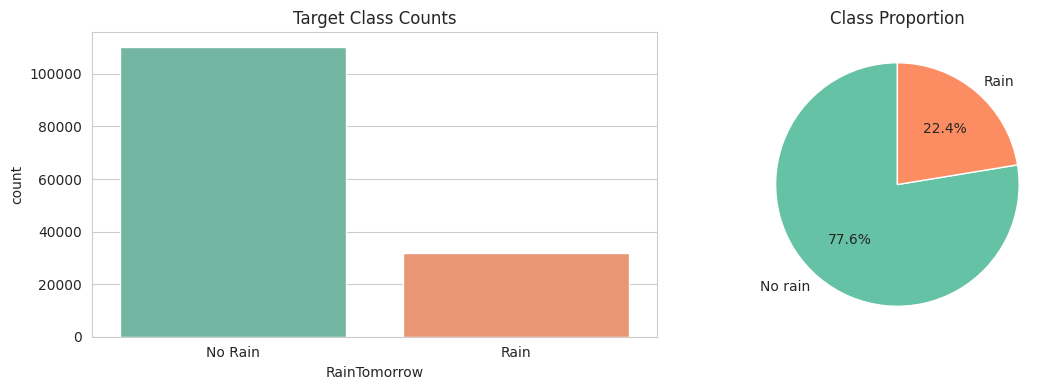


Class balance (%):
RainTomorrow
No     77.58
Yes    22.42
Name: count, dtype: float64


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
target_counts = df['RainTomorrow'].value_counts().sort_index()
sns.countplot(data=df, x='RainTomorrow', ax=axes[0], palette='Set2')
axes[0].set_title('Target Class Counts')
axes[0].set_xticklabels(['No Rain', 'Rain'])
axes[1].pie(target_counts, labels=['No rain', 'Rain'], autopct='%1.1f%%',
            colors=['#66c2a5', '#fc8d62'], startangle=90)
axes[1].set_title('Class Proportion')
plt.tight_layout(); plt.show()
print('\nClass balance (%):')
print((target_counts / target_counts.sum() * 100).round(2))

#5. Univariate Analysis - Numeric Features

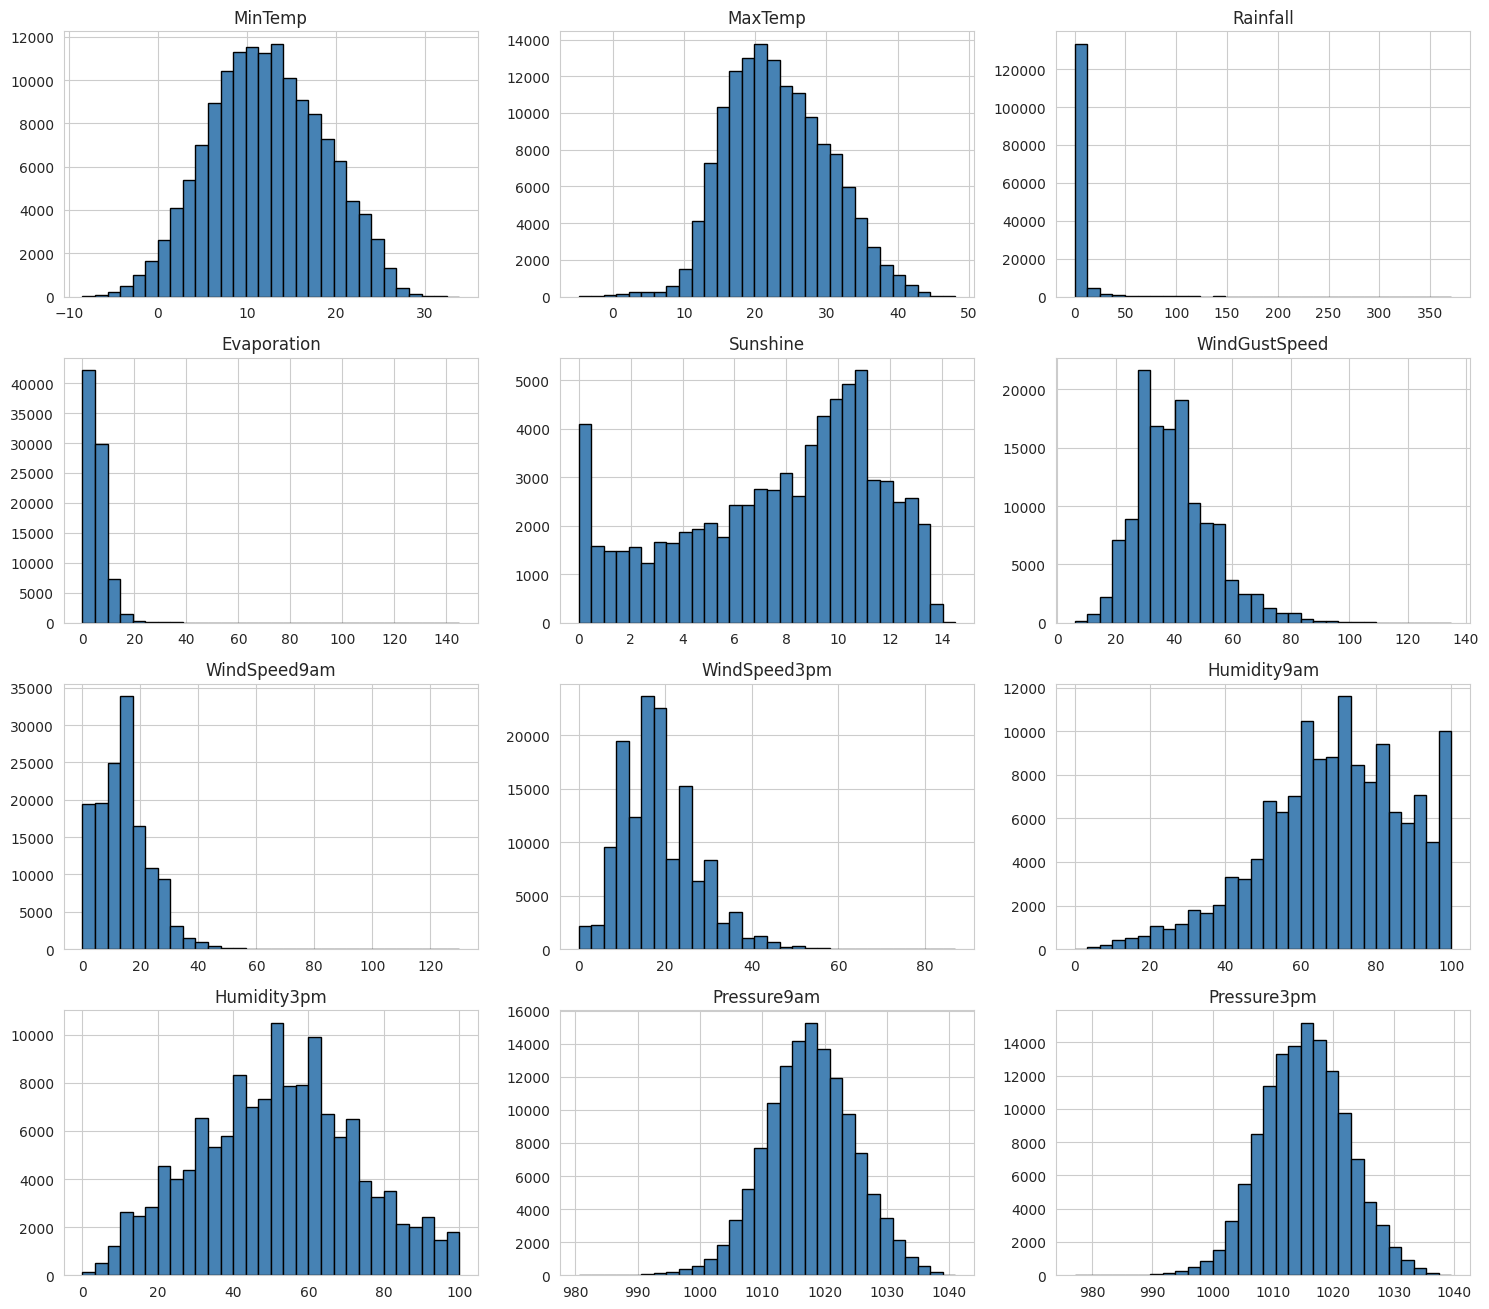

In [23]:
import math

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

n_show = min(len(numeric_cols), 12)
ncols = 3
nrows = math.ceil(n_show / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3.3*nrows))
axes = np.array(axes).reshape(-1)
for i, col in enumerate(numeric_cols[:n_show]):
  df[col].hist(ax=axes[i], bins=30, color='steelblue', edgecolor='black')
  axes[i].set_title(col)
for j in range(n_show, len(axes)):
  axes[j].axis('off') # Corrected 'axiz' to 'axis'
plt.tight_layout(); plt.show()

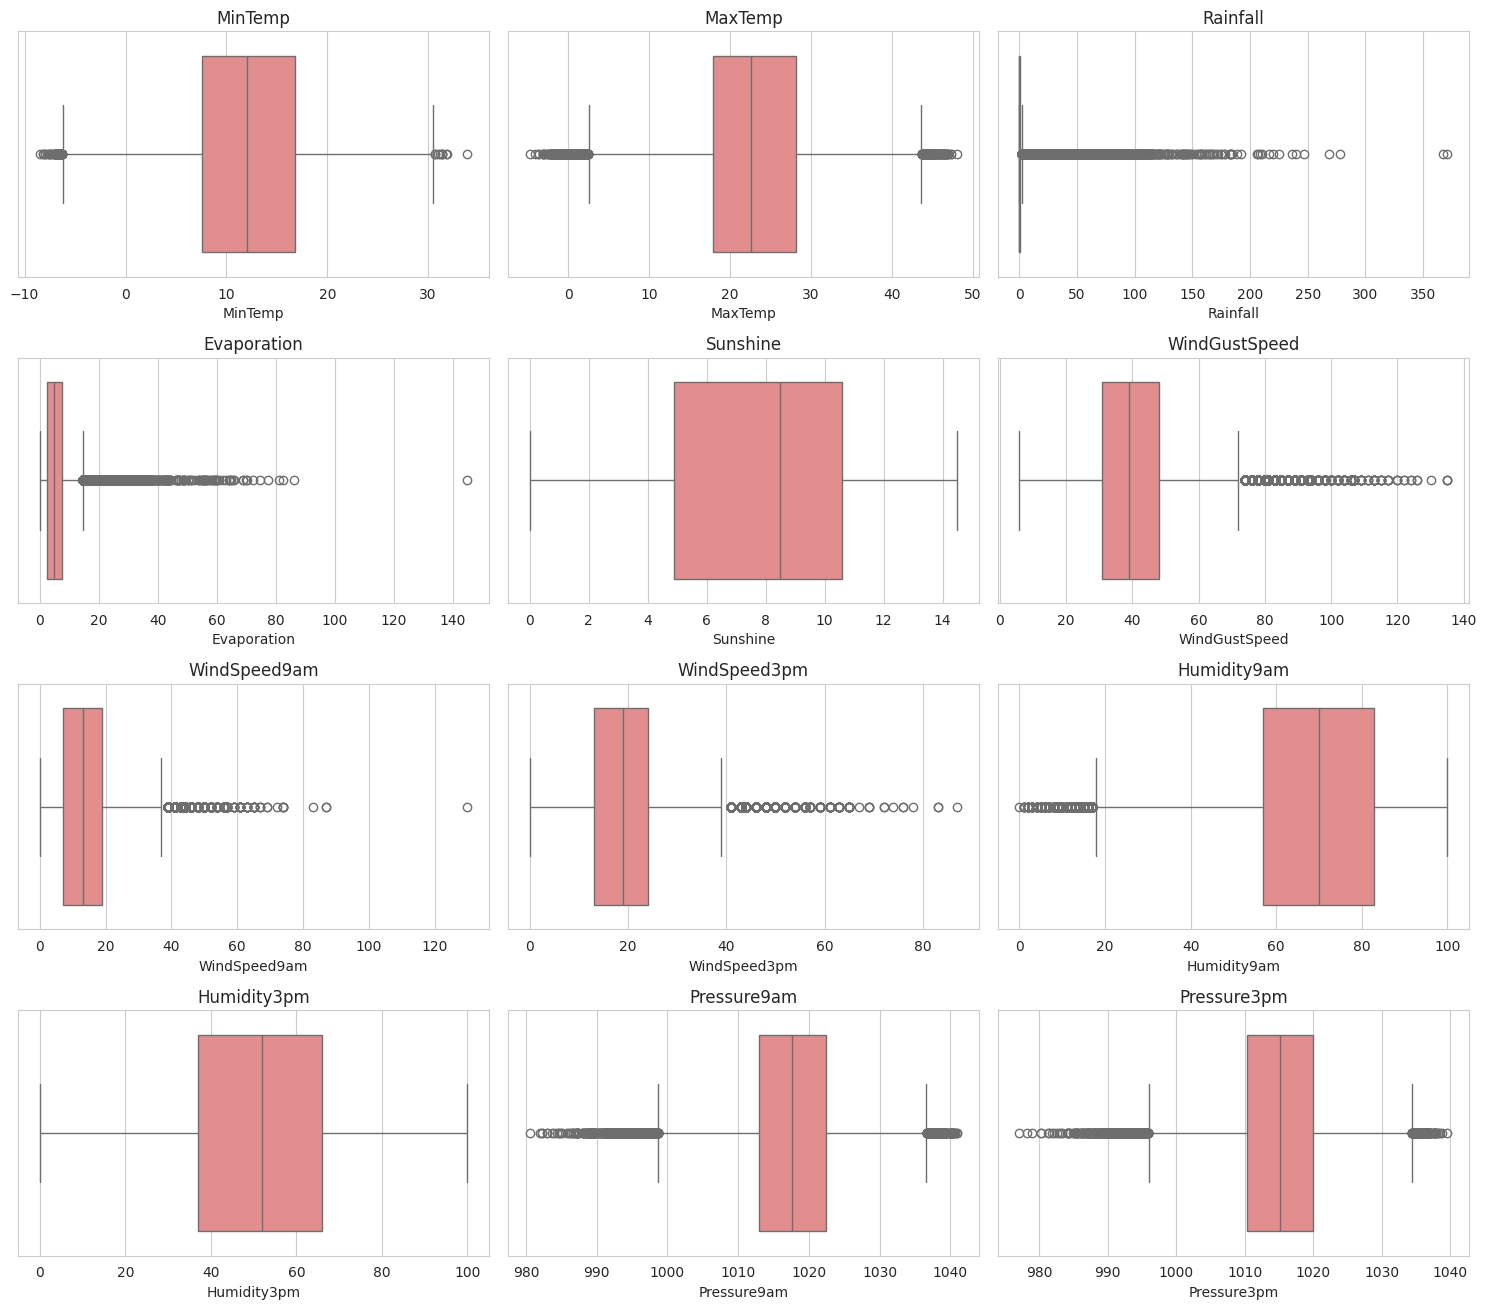

In [25]:
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3.3*nrows))
axes = np.array(axes).reshape(-1)
for i, col in enumerate(numeric_cols[:n_show]):
  sns.boxplot(x=df[col], ax=axes[i], color='lightcoral')
  axes[i].set_title(col)
for j in range(n_show, len(axes)):
  axes[j].axis('off')
plt.tight_layout(); plt.show()

#6. Bivariate Analysis - Features vs Target

In [27]:
# Convert 'RainTomorrow' to numerical (0 for No, 1 for Yes)
df['RainTomorrow_numeric'] = df['RainTomorrow'].map({'No': 0, 'Yes': 1})

# Now calculate correlations using the numerical version
corrs_all = df[numeric_cols + ['RainTomorrow_numeric']].corr()['RainTomorrow_numeric'].abs().sort_values(ascending=False)
top_features = [c for c in corrs_all.index if c != 'RainTomorrow_numeric'][:6]
print('Top features by |correlation | with target:')
print(corrs_all[top_features].round(3))

Top features by |correlation | with target:
Sunshine       0.451
Humidity3pm    0.446
Cloud3pm       0.382
Cloud9am       0.317
Humidity9am    0.257
Pressure9am    0.246
Name: RainTomorrow_numeric, dtype: float64


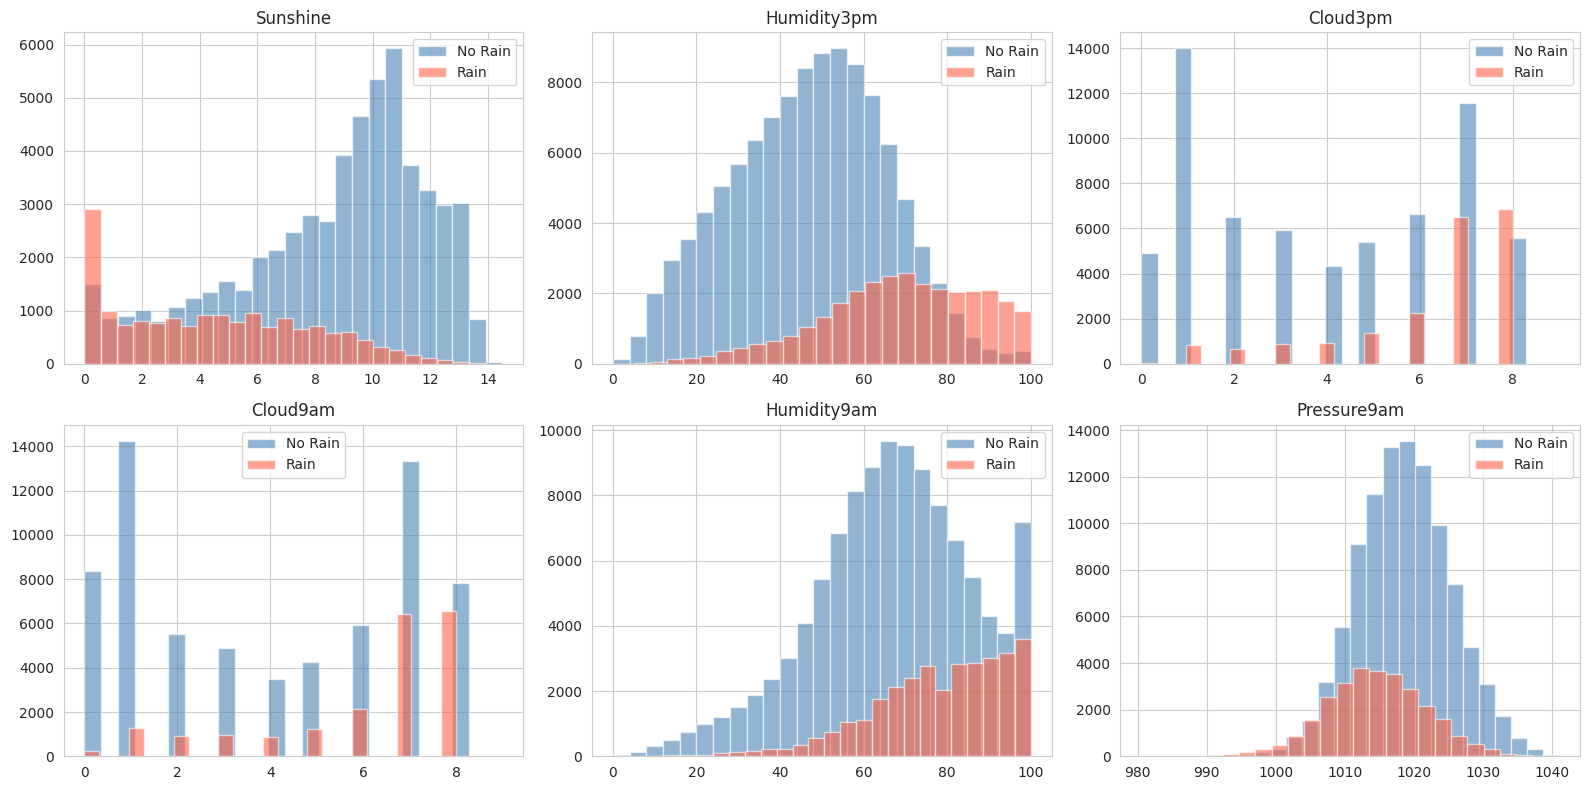

In [29]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
labels = ['No Rain', 'Rain']
colors = ['steelblue', 'tomato']
for i, col in enumerate(top_features[:6]):
  for cls, lbl, c in [(0, labels[0], colors[0]), (1, labels[1], colors[1])]:
    axes[i].hist(df[df['RainTomorrow_numeric']==cls][col].dropna(), bins=25, alpha=0.6, label=lbl, color=c)
  axes[i].set_title(col); axes[i].legend()
plt.tight_layout(); plt.show()

In [30]:
means = df.groupby('RainTomorrow')[numeric_cols].mean().T
means.columns = ['No Rain', 'Rain']
means['Difference'] = means.iloc[:, 1] - means.iloc[:, 0]
means.sort_values('Difference', key=abs, ascending=False).round(3).head(15)

,No Rain,Rain,Difference
Humidity3pm,46.511,68.800,22.289
Humidity9am,66.218,77.983,11.766
WindGustSpeed,38.288,45.947,7.658
Rainfall,1.270,6.142,4.872
Pressure9am,1018.596,1014.400,-4.196
Sunshine,8.546,4.472,-4.075
Pressure3pm,1016.114,1012.301,-3.813
Temp3pm,22.403,19.197,-3.206
MaxTemp,23.836,21.119,-2.717
Cloud3pm,3.922,6.360,2.438


#7. Correlation Analysis

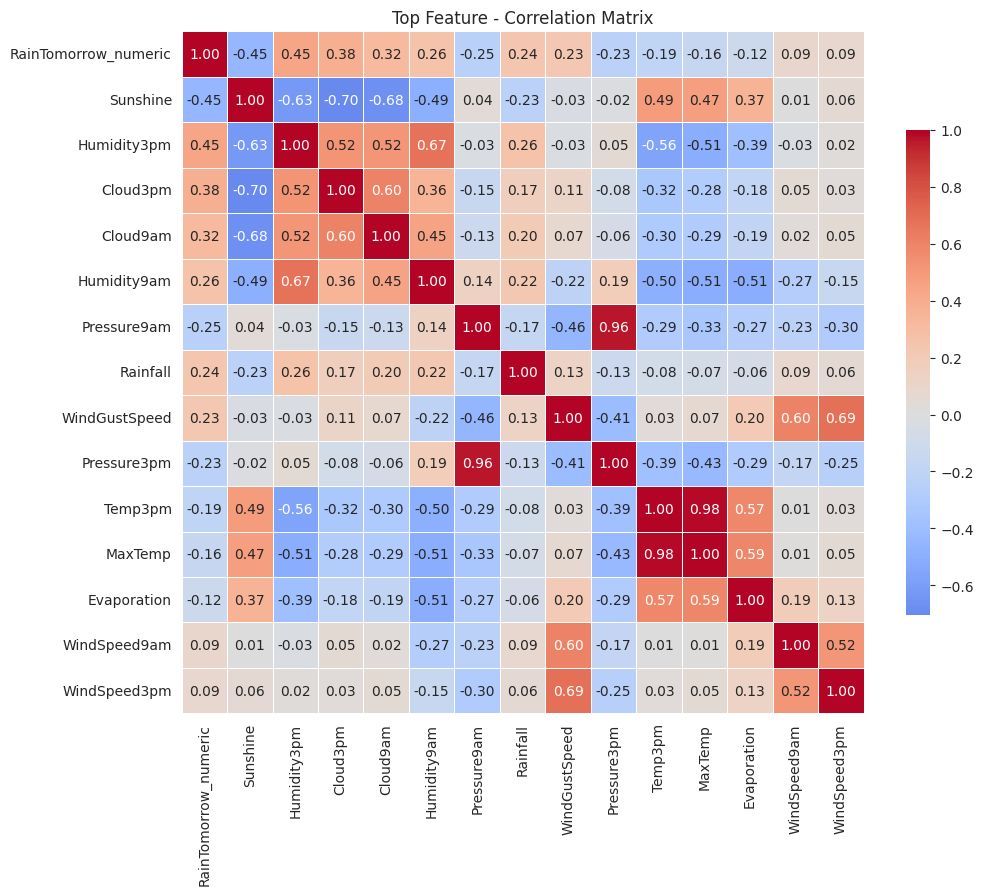

In [32]:
top_numeric = corrs_all.head(15).index.tolist()

if 'RainTomorrow' in top_numeric:
  top_numeric.remove('RainTomorrow')
if 'RainTomorrow_numeric' not in top_numeric:
  top_numeric.append('RainTomorrow_numeric')

corr_matrix = df[top_numeric].corr
plt.figure(figsize=(11, 9))
sns.heatmap(corr_matrix(), annot=True, cmap='coolwarm', fmt='.2f', center=0,
            square=True, linewidth=0.5, cbar_kws={'shrink': 0.7})
plt.title('Top Feature - Correlation Matrix'); plt.tight_layout; plt.show()

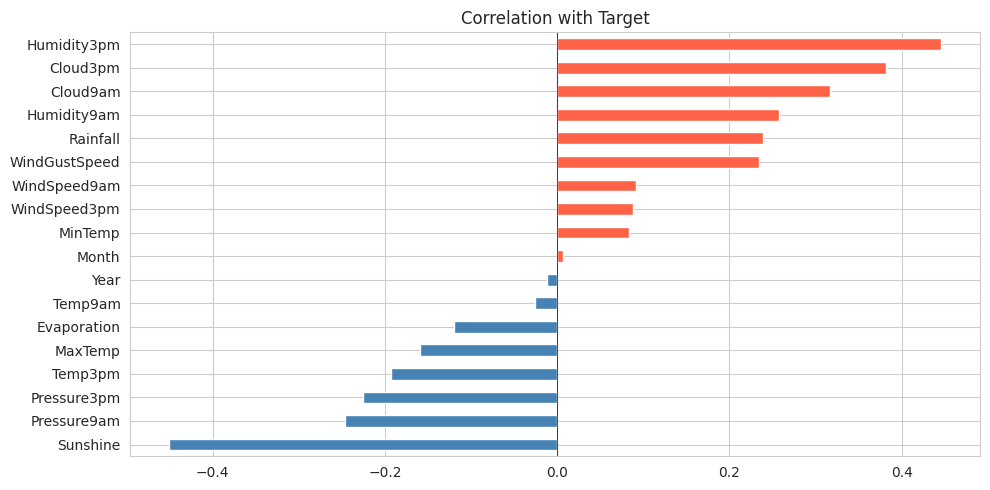

In [34]:
target_corr = df[numeric_cols + ['RainTomorrow_numeric']].corr()['RainTomorrow_numeric'].drop('RainTomorrow_numeric').sort_values()
plt.figure(figsize=(10, max(5, len(target_corr)*0.25)))
colors = ['tomato' if v > 0 else 'steelblue' for v in target_corr]
target_corr.plot(kind='barh', color=colors)
plt.title('Correlation with Target')
plt.axvline(0, color='black', linewidth=0.5)
plt.tight_layout(); plt.show()

#8. Domain Deep-Dive - Geography, Season, and Weather Drivers

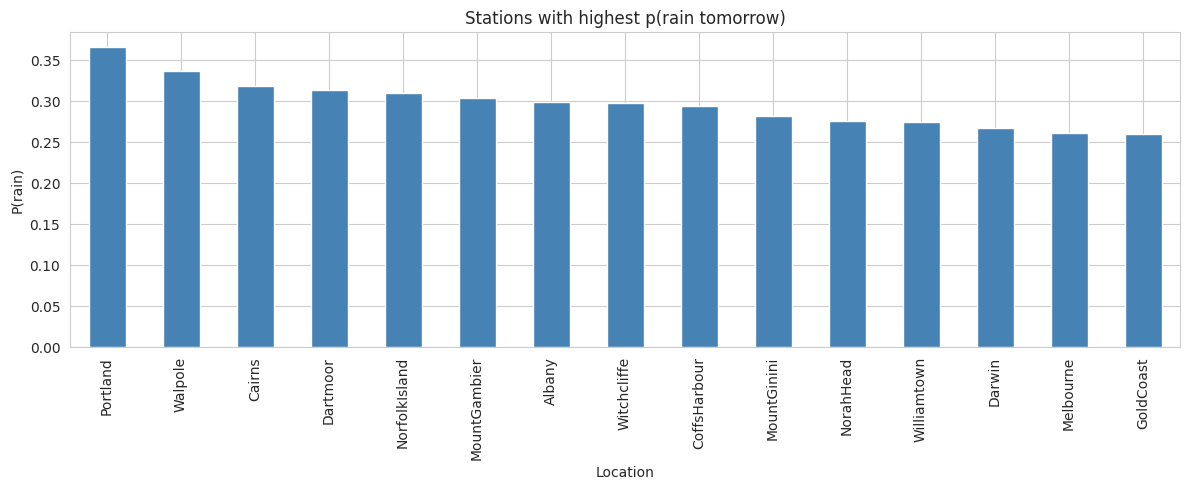

In [36]:
#Top statistics by rain-tomorrow rate
by_loc = df.groupby('Location')['RainTomorrow_numeric'].agg(['mean', 'count'])
by_loc = by_loc[by_loc['count'] > 200].sort_values('mean', ascending=False)
fig, ax = plt.subplots(figsize=(12, 5))
by_loc['mean'].head(15).plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Stations with highest p(rain tomorrow)'); ax.set_ylabel('P(rain)')

plt.tight_layout(); plt.show()

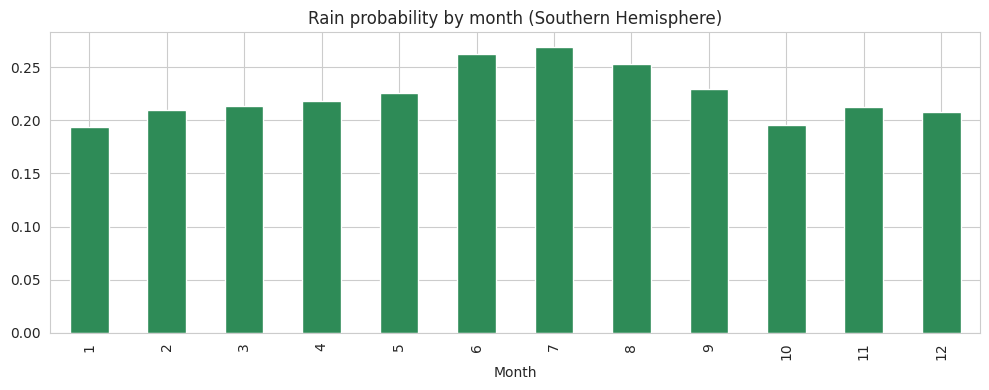

In [38]:
#Rain rate by month
if 'Month' in df.columns:
  fig, ax = plt.subplots(figsize=(10, 4))
  df.groupby('Month')['RainTomorrow_numeric'].mean().plot(kind='bar', ax=ax, color='seagreen')
  ax.set_title('Rain probability by month (Southern Hemisphere)')
  plt.tight_layout(); plt.show()

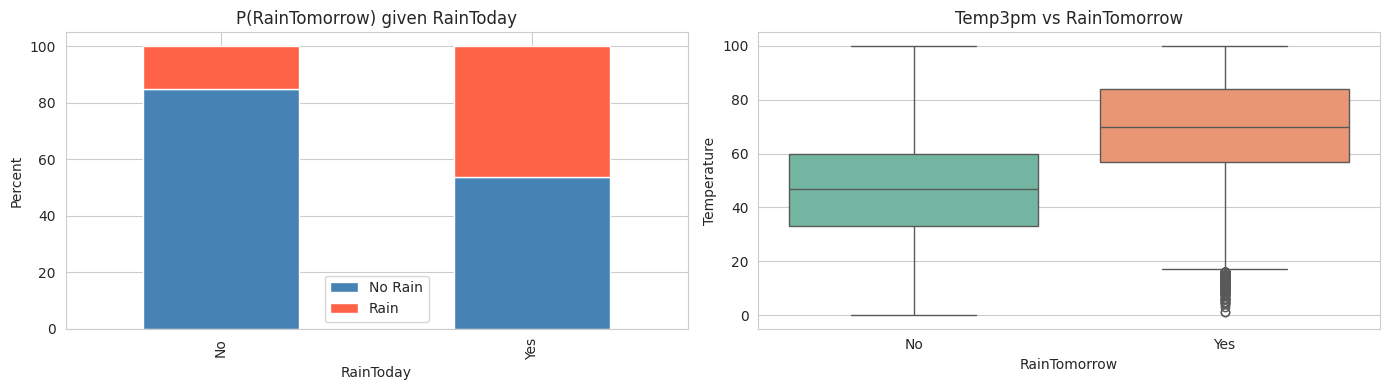

In [40]:
# RainToday is a strong leading indicator
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
ct = pd.crosstab(df['RainToday'], df['RainTomorrow'], normalize='index') * 100
ct.plot(kind='bar', stacked=True, ax=axes[0], color=['steelblue', 'tomato'])
axes[0].set_title('P(RainTomorrow) given RainToday')
axes[0].set_ylabel('Percent'); axes[0].legend(['No Rain', 'Rain'])
sns.boxplot(x='RainTomorrow', y='Humidity3pm', data=df, ax=axes[1], palette='Set2')
axes[1].set_title('Temp3pm vs RainTomorrow'); axes[1].set_ylabel('Temperature')
plt.tight_layout(); plt.show()

#9. Pair Plot of Top Features

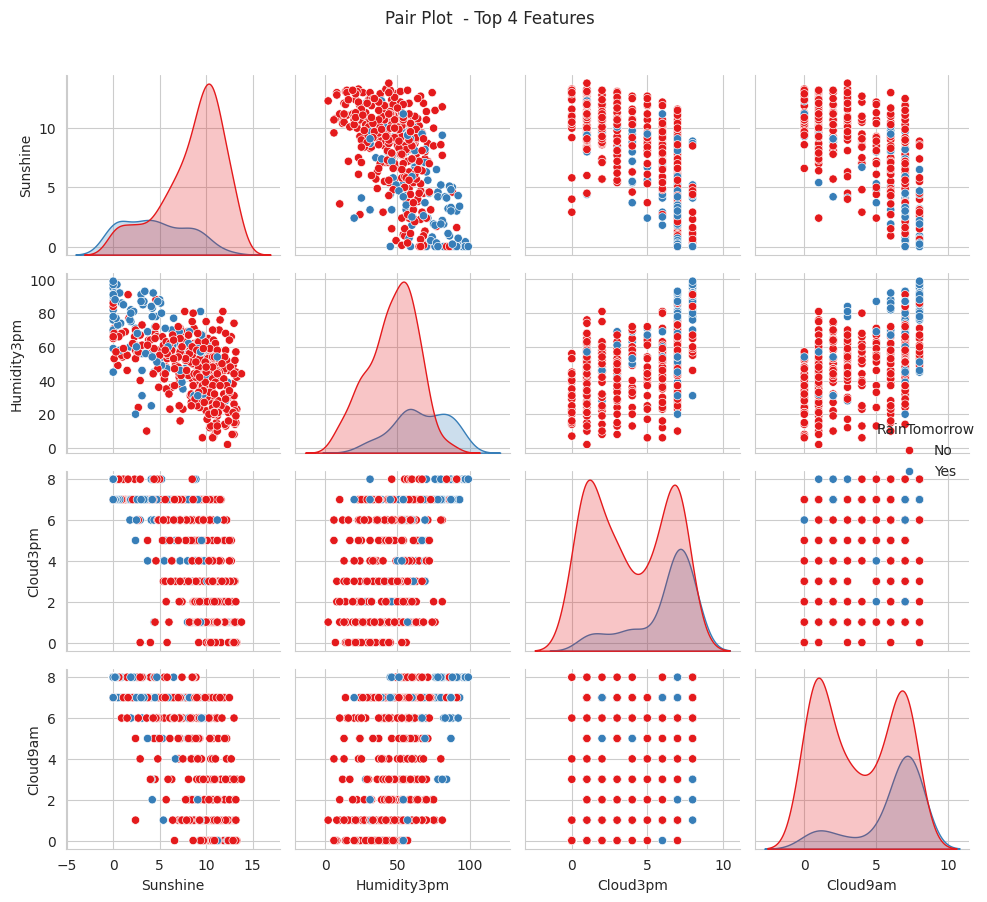

In [41]:
sample = df.sample(min(1000, len(df)), random_state=42)
sns.pairplot(sample[top_features[:4] + ['RainTomorrow']].dropna(),
             hue='RainTomorrow', palette='Set1', diag_kind='kde', height=2.2)
plt.suptitle('Pair Plot  - Top 4 Features', y=1.02); plt.tight_layout(); plt.show()

#10. Summary of Key Findings

In [42]:
summary = pd.DataFrame({
    'Metric':['Total samples', 'Total features', 'Class 0 count', 'Class 1 count',
              'Class imbalance ratio', 'Top correlated feature', 'Top correlation value'],

    'Value':[
        len(df),
        df.shape[1] - 1,
        int((df['RainTomorrow'] == 0).sum()),
        int((df['RainTomorrow'] == 1).sum()),
        f"{(df['RainTomorrow'] == 0).sum() / max(1, (df['RainTomorrow'] == 1).sum()):.2f}:1",
        top_features[0],
        round(corrs_all[top_features[0]], 3),
    ],
})
summary

,Metric,Value
0,Total samples,142193
1,Total features,24
2,Class 0 count,0
3,Class 1 count,0
4,Class imbalance ratio,0.00:1
5,Top correlated feature,Sunshine
6,Top correlation value,0.451
